# 🍎 FrostGuard-Scab — Train a YOLO11n Apple Scab Detector on Google Colab

<a href="https://colab.research.google.com/github/peerzadarabet1807/frostguard-scab/blob/main/notebooks/train_yolo_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook does all of the GPU work for **FrostGuard-Scab**, so the local stack can stay light and run on ONNX Runtime alone.

| Step | What happens |
|---|---|
| 1 | Mount Google Drive (checkpoints + exported model survive Colab disconnects) |
| 2 | Install `ultralytics` + `roboflow` |
| 3 | Download an **Apple Scab** detection dataset from Roboflow Universe |
| 4 | Fine-tune **YOLO11-Nano** (`yolo11n.pt`, ~2.6 M params) for 15–25 epochs on a **T4 GPU** |
| 5 | Evaluate (mAP, PR curve, confusion matrix, sample predictions) |
| 6 | Export to **ONNX** → `scab_detector.onnx` and save it to Drive |
| 7 | Verify the export with ONNX Runtime on CPU (the same runtime the local API uses) |

**Before you start:** `Runtime ▸ Change runtime type ▸ T4 GPU`, and add your free Roboflow API key as a Colab secret named `ROBOFLOW_API_KEY` (🔑 icon in the left sidebar). If the secret isn't set, the notebook will prompt for the key instead.

⏱️ Expected runtime: about 10–20 minutes end to end on a T4.

## 0 · Runtime check

In [1]:
!nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv

import platform
import torch

print(f"Python {platform.python_version()} | torch {torch.__version__}")
assert torch.cuda.is_available(), "No GPU found - switch to Runtime > Change runtime type > T4 GPU"
print("GPU:", torch.cuda.get_device_name(0))

name, memory.total [MiB], driver_version
Tesla T4, 15360 MiB, 580.82.07
Python 3.13.15 | torch 2.11.0+cu128
GPU: Tesla T4


## 1 · Mount Google Drive
Runs are written straight to Drive, so a Colab disconnect never loses your checkpoints.

In [2]:
from pathlib import Path

from google.colab import drive

drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/frostguard-scab")
RUNS_DIR = DRIVE_ROOT / "runs"      # training checkpoints & plots
EXPORT_DIR = DRIVE_ROOT / "models"  # final ONNX model
for d in (RUNS_DIR, EXPORT_DIR):
    d.mkdir(parents=True, exist_ok=True)
print("Drive workspace:", DRIVE_ROOT)

Mounted at /content/drive
Drive workspace: /content/drive/MyDrive/frostguard-scab


## 2 · Install dependencies

In [3]:
%pip install -q "ultralytics>=8.3" "roboflow>=1.1" onnx onnxslim onnxruntime

import ultralytics

ultralytics.checks()

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.6/235.7 GB disk)


## 3 · Configuration

The default dataset is [**PDD – Apple – Scab**](https://universe.roboflow.com/thesis-okplj/pdd-apple-scab) on Roboflow Universe (CC BY 4.0).
To use another Apple Scab detection project, change the three `ROBOFLOW_*` values. Any Roboflow object-detection project works.

In [4]:
# --- Dataset (Roboflow Universe) --------------------------------------------
ROBOFLOW_WORKSPACE = "thesis-okplj"
ROBOFLOW_PROJECT = "pdd-apple-scab"
ROBOFLOW_VERSION = None  # None -> latest published version

# --- Training ------------------------------------------------------------------
BASE_WEIGHTS = "yolo11n.pt"  # YOLO11-Nano, COCO-pretrained
EPOCHS = 20                  # 15-25 is plenty for fine-tuning on a T4
IMGSZ = 640
BATCH = 16
PATIENCE = 8                 # early stopping
SEED = 42
RUN_NAME = "scab_yolo11n"
EXPORT_NAME = "scab_detector.onnx"

## 4 · Download the dataset from Roboflow Universe

In [5]:
import os
from getpass import getpass

from roboflow import Roboflow

api_key = None
try:
    from google.colab import userdata

    api_key = userdata.get("ROBOFLOW_API_KEY")
except Exception:  # secret missing or notebook access not granted
    api_key = os.environ.get("ROBOFLOW_API_KEY")
if not api_key:
    api_key = getpass("Roboflow API key: ")

rf = Roboflow(api_key=api_key)
project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
if ROBOFLOW_VERSION is None:
    ROBOFLOW_VERSION = max(int(str(v.version).split("/")[-1]) for v in project.versions())
print(f"Dataset: {ROBOFLOW_WORKSPACE}/{ROBOFLOW_PROJECT} v{ROBOFLOW_VERSION}")

dataset = project.version(ROBOFLOW_VERSION).download("yolov11", location="/content/datasets/apple-scab")
DATA_YAML = f"{dataset.location}/data.yaml"

loading Roboflow workspace...
loading Roboflow project...
Dataset: thesis-okplj/pdd-apple-scab v1



Extracting Dataset Version Zip to /content/datasets/apple-scab in yolov11:: 100%|██████████| 403/403 [00:00<00:00, 10550.56it/s]


### Inspect the dataset and pin split paths
Roboflow writes relative paths into `data.yaml`. Rewriting them as absolute paths avoids the common *"images not found"* error.

In [8]:
import random
import shutil

import yaml

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
root = Path(dataset.location)


def images_in(split):
    folder = root / split / "images"
    return sorted(p for p in folder.glob("*") if p.suffix.lower() in IMG_EXTS) if folder.is_dir() else []


for split in ("train", "valid", "val", "test"):
    print(f"{split:>5}: {len(images_in(split))} images")
assert images_in("train"), f"No training images under {root / 'train' / 'images'}; check the Roboflow export."

# Roboflow versions differ: train/valid/test, train/test, or train only.
val_split = next((s for s in ("valid", "val") if images_in(s)), None)
test_split = "test" if images_in("test") else None
if val_split is None and test_split is not None:
    val_split, test_split = test_split, None
    print("No validation split in this version: validating on test/.")
elif val_split is None:
    # Hold out a reproducible 20 % of train/ (images + YOLO label files) as valid/.
    train_images = images_in("train")
    random.Random(SEED).shuffle(train_images)
    n_val = max(1, round(0.2 * len(train_images)))
    for sub in ("images", "labels"):
        (root / "valid" / sub).mkdir(parents=True, exist_ok=True)
    for img in train_images[:n_val]:
        shutil.move(str(img), str(root / "valid" / "images" / img.name))
        label = root / "train" / "labels" / f"{img.stem}.txt"
        if label.exists():
            shutil.move(str(label), str(root / "valid" / "labels" / label.name))
    val_split = "valid"
    print(f"No validation split in this version: moved {n_val} random train images to valid/.")

# Roboflow writes relative paths into data.yaml; absolute ones avoid "images not found" errors.
with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)
cfg["path"] = str(root)
cfg["train"] = str(root / "train" / "images")
cfg["val"] = str(root / val_split / "images")
if test_split:
    cfg["test"] = str(root / test_split / "images")
else:
    cfg.pop("test", None)
with open(DATA_YAML, "w") as f:
    yaml.safe_dump(cfg, f)

VAL_IMAGES = cfg["val"]
print(f"-> train: {len(images_in('train'))} | val ({val_split}): {len(images_in(val_split))} | classes: {cfg['names']}")

train: 200 images
valid: 0 images
  val: 0 images
 test: 0 images
No validation split in this version: moved 40 random train images to valid/.
-> train: 160 | val (valid): 40 | classes: ['Apple - Scab']


## 5 · Fine-tune YOLO11n

Augmentations are set for field photos: leaves show up at any orientation and under changing light. Hue jitter stays small because lesion **colour** carries signal (olive-brown scab versus green tissue).

In [9]:
from ultralytics import YOLO

model = YOLO(BASE_WEIGHTS)
results = model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    patience=PATIENCE,
    device=0,
    seed=SEED,
    project=str(RUNS_DIR),
    name=RUN_NAME,
    exist_ok=True,
    cos_lr=True,
    close_mosaic=5,
    degrees=10.0,
    flipud=0.5,
    fliplr=0.5,
    hsv_h=0.01,
    hsv_s=0.5,
    hsv_v=0.4,
    plots=True,
)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=5, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/datasets/apple-scab/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.5, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=scab_yolo11n, nbs=64, nms=None, opset=No

<details><summary>Colab disconnected mid-training?</summary>

Run the cell below to resume from the last checkpoint on Drive.
</details>

In [10]:
# Uncomment to resume an interrupted run:
# model = YOLO(str(RUNS_DIR / RUN_NAME / "weights" / "last.pt"))
# results = model.train(resume=True)

## 6 · Evaluate

In [11]:
BEST = RUNS_DIR / RUN_NAME / "weights" / "best.pt"
best = YOLO(str(BEST))
metrics = best.val(data=DATA_YAML, imgsz=IMGSZ, split="val", plots=True)
print(
    f"mAP50: {metrics.box.map50:.3f} | mAP50-95: {metrics.box.map:.3f} | "
    f"precision: {metrics.box.mp:.3f} | recall: {metrics.box.mr:.3f}"
)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 577.7±259.4 MB/s, size: 13.7 KB)
val: Scanning /content/datasets/apple-scab/valid/labels.cache... 40 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 40/40 14.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.4it/s 2.1s
                   all         40        217      0.447      0.585      0.531      0.224
Speed: 5.1ms preprocess, 11.9ms inference, 0.0ms loss, 7.0ms postprocess per image
Results saved to /content/runs/detect/val
mAP50: 0.531 | mAP50-95: 0.224 | precision: 0.447 | recall: 0.585


results.png


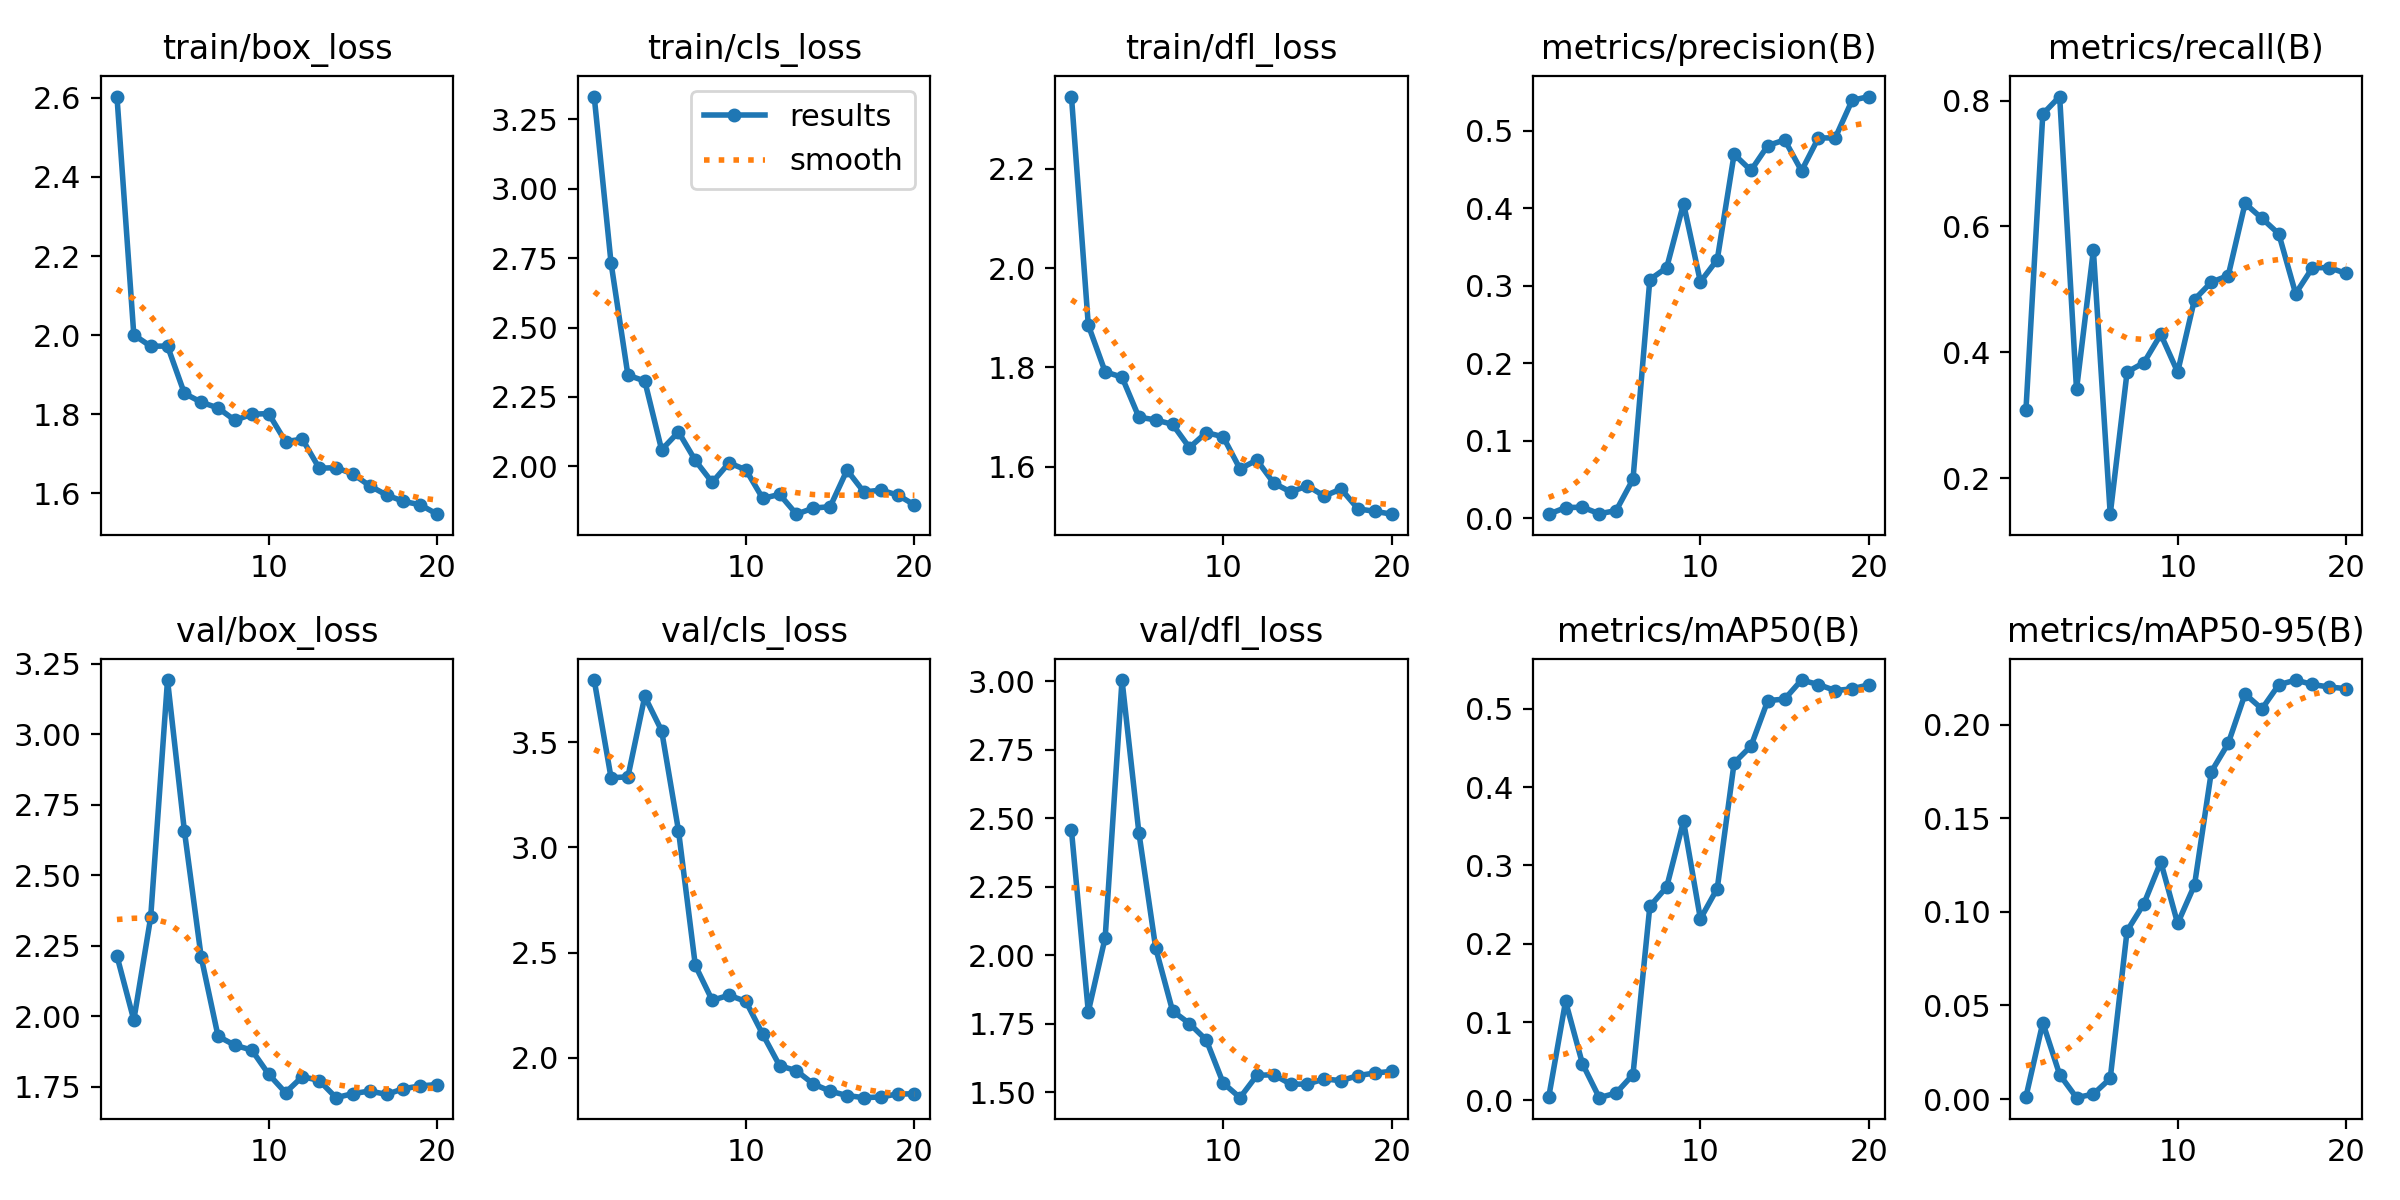

BoxPR_curve.png


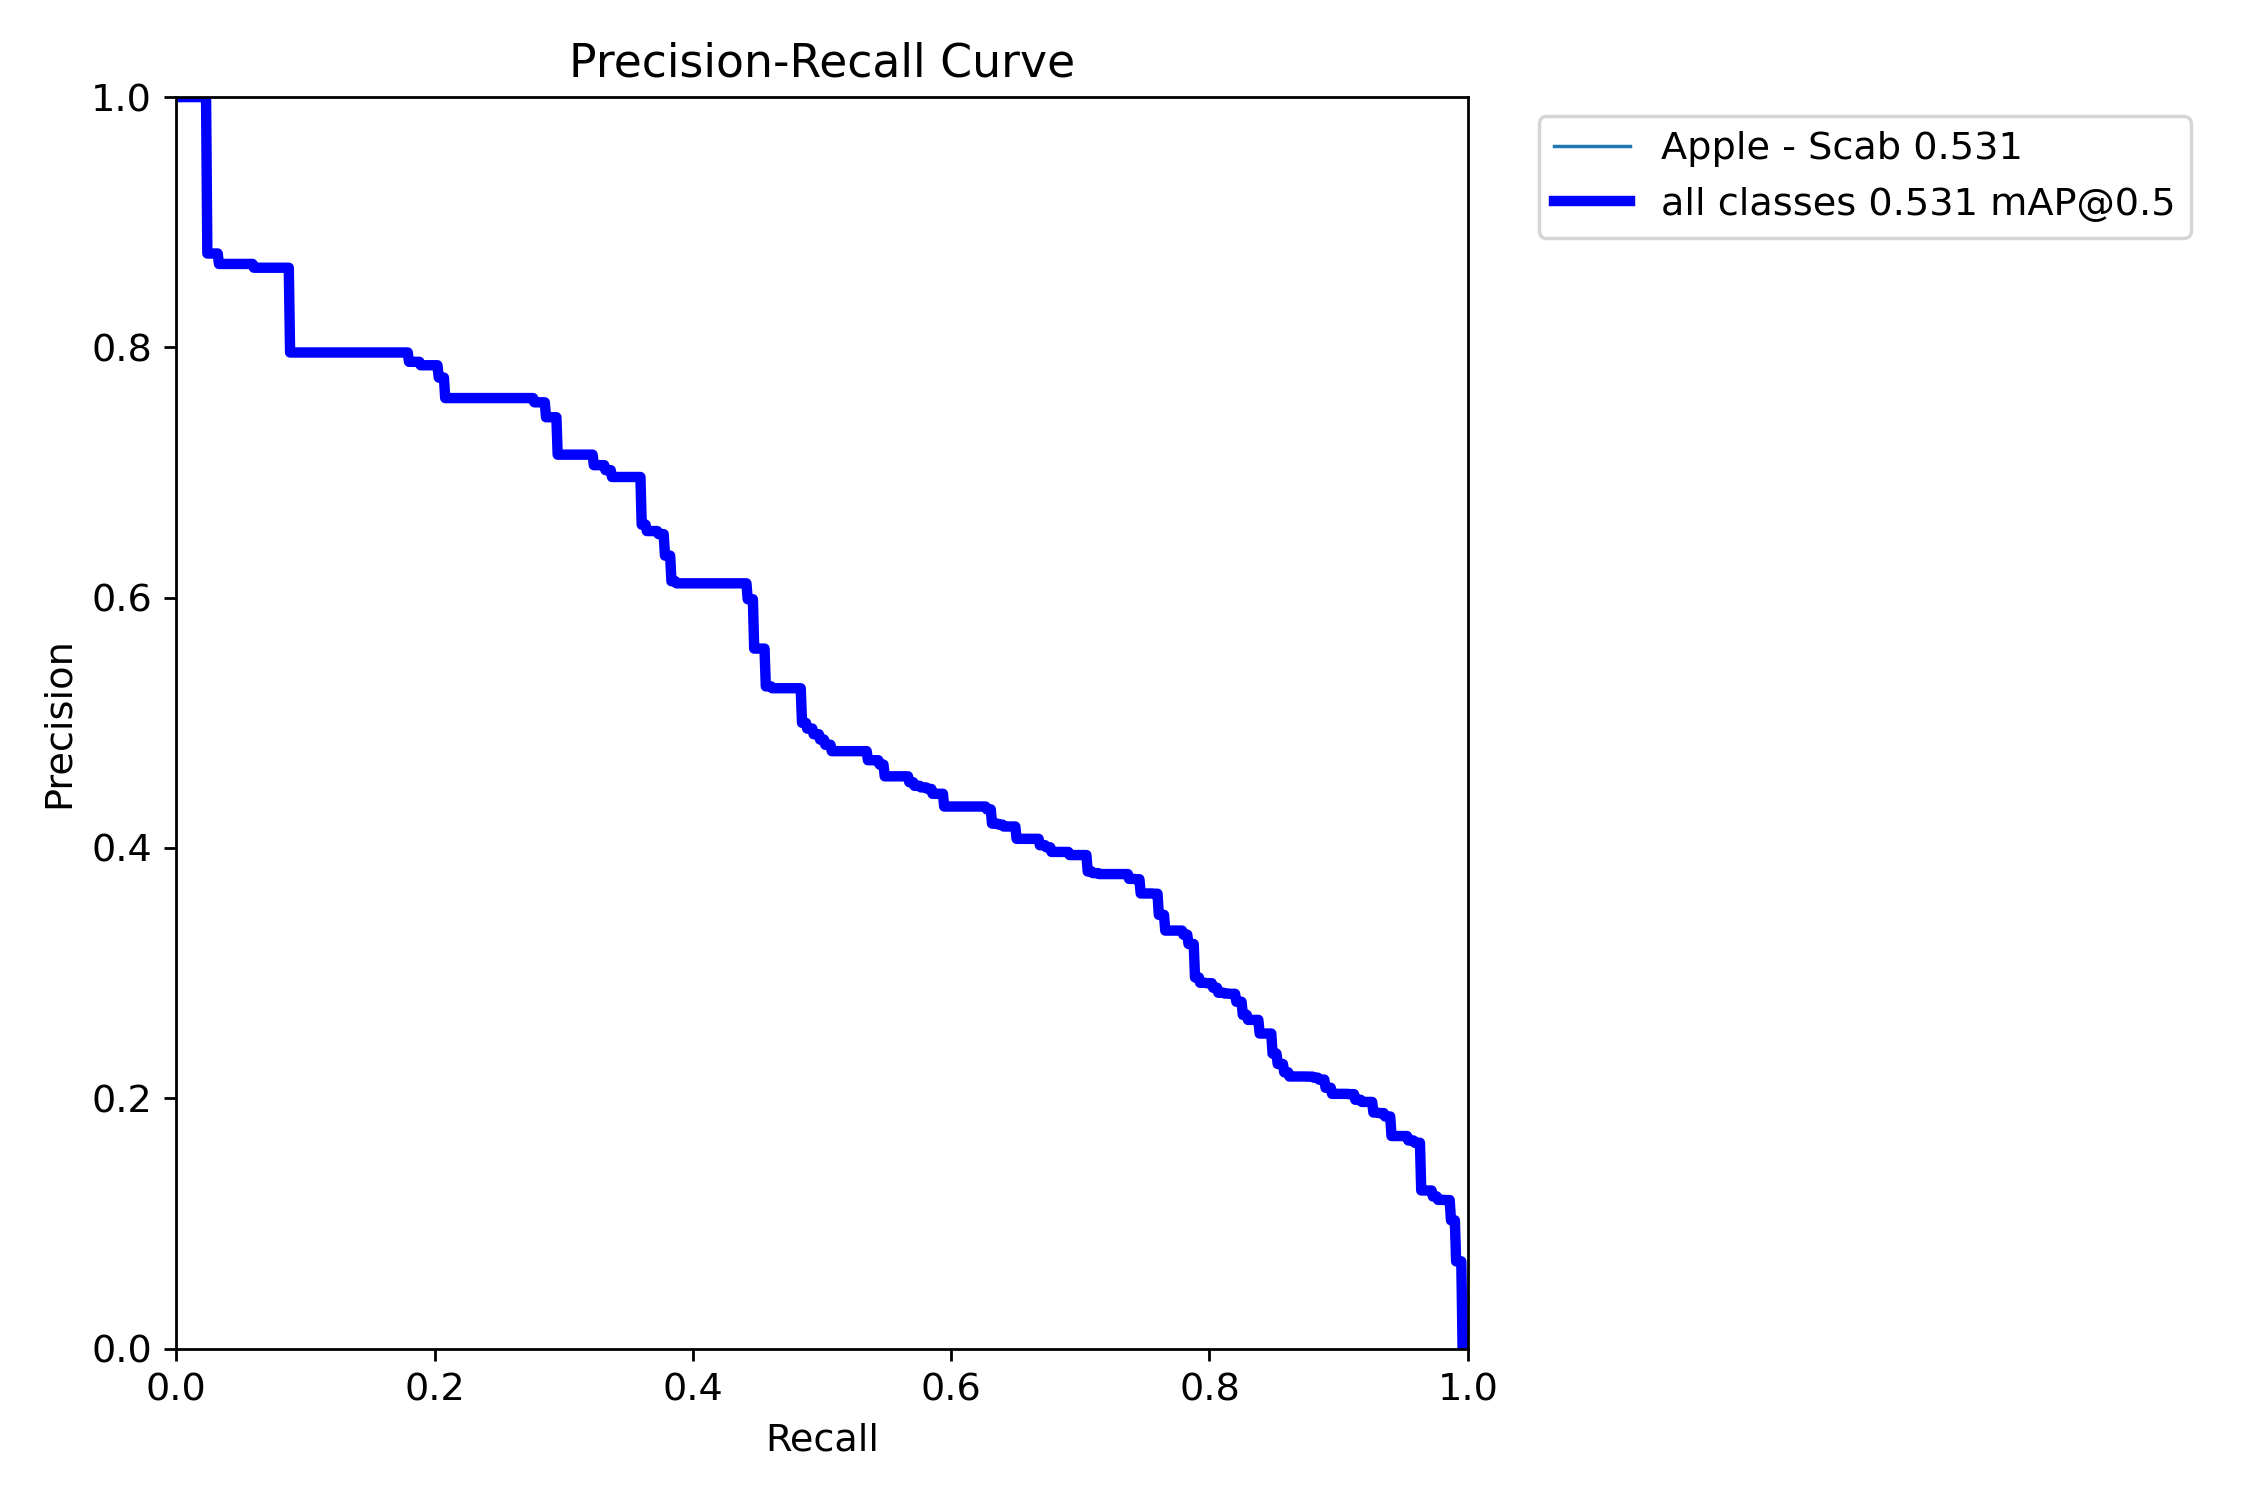

confusion_matrix_normalized.png


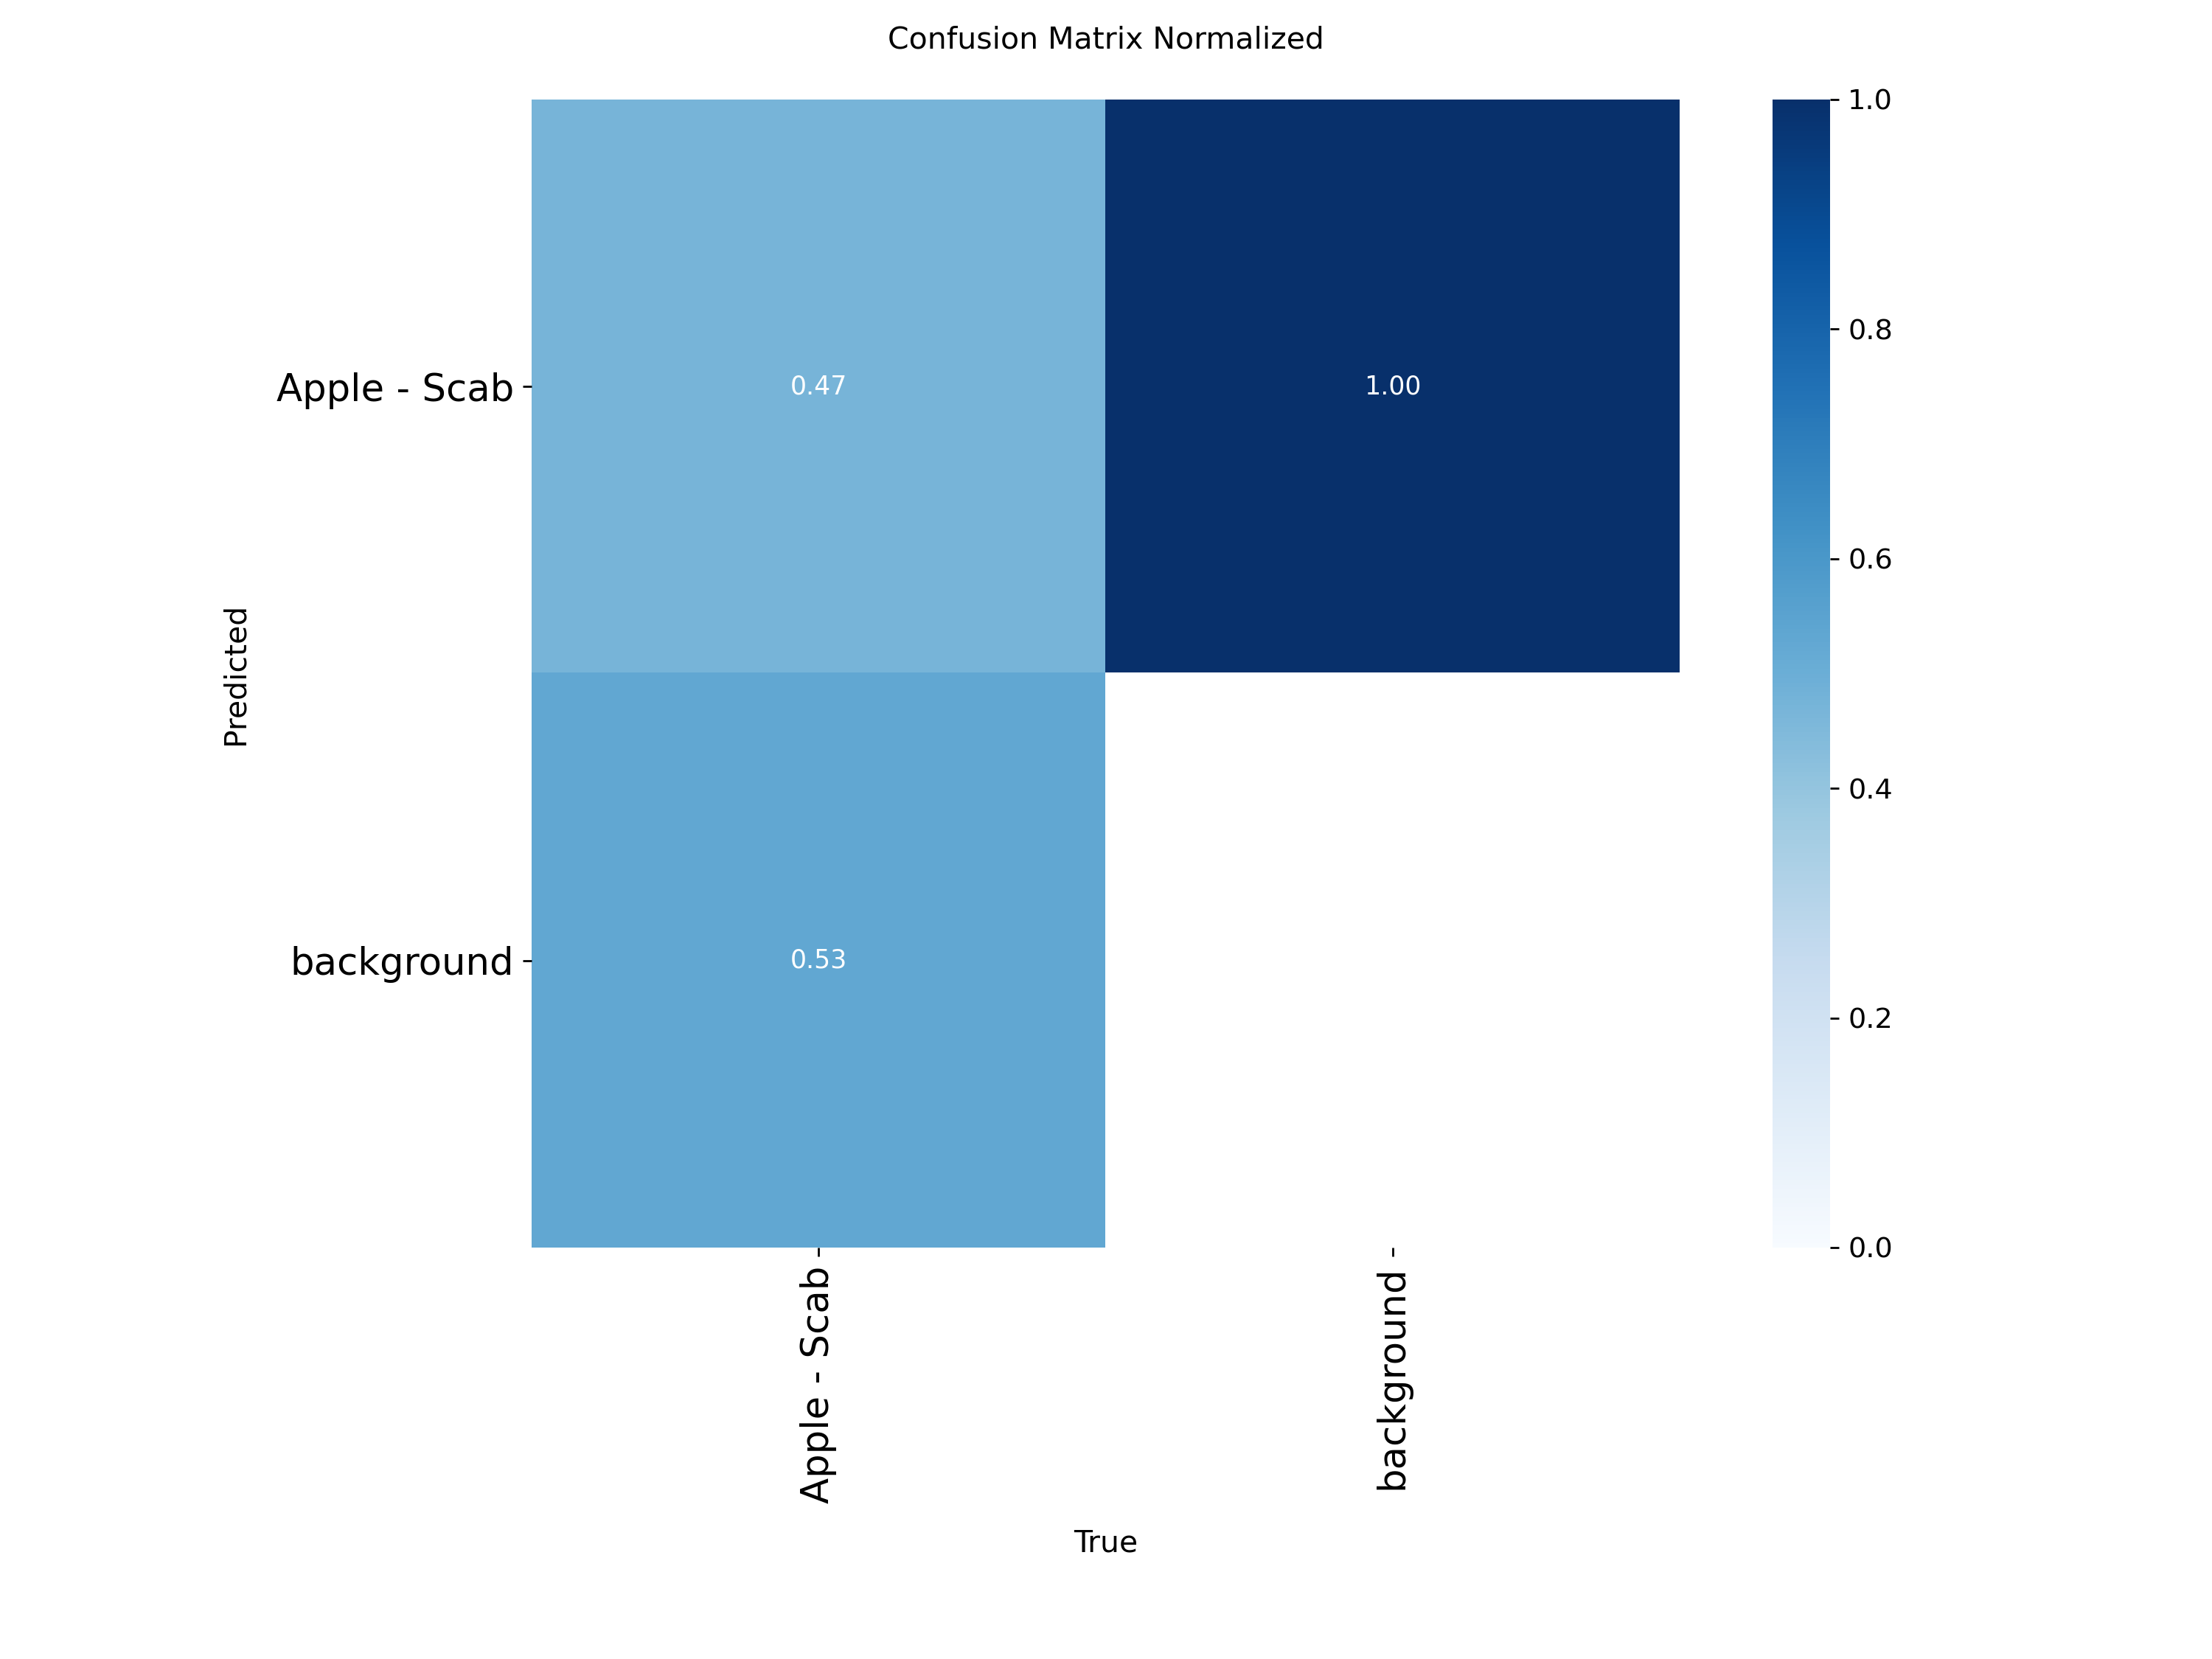

In [12]:
from IPython.display import Image as IPImage
from IPython.display import display

run_dir = RUNS_DIR / RUN_NAME
for name in ("results.png", "BoxPR_curve.png", "PR_curve.png", "confusion_matrix_normalized.png"):
    path = run_dir / name
    if path.exists():
        print(name)
        display(IPImage(filename=str(path), width=900))

### Sample predictions on held-out images


0: 640x640 2 Apple - Scabs, 5.5ms
1: 640x640 4 Apple - Scabs, 5.5ms
2: 640x640 9 Apple - Scabs, 5.5ms
3: 640x640 4 Apple - Scabs, 5.5ms
Speed: 1.9ms preprocess, 5.5ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/drive/MyDrive/frostguard-scab/runs/scab_yolo11n_pred
270dd6be-95f4-4fd1-8423-b698663b3f72___FREC_Scab-2954_JPG.rf.330e7acaf16860b18c4847ca317b908d.jpg -> 2 lesion(s)


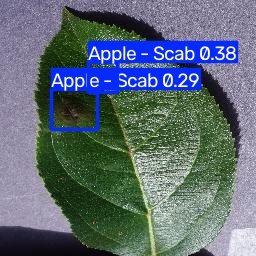

058d5e64-2c57-45ba-94cb-ac83fd1885a0___FREC_Scab-3181_JPG.rf.57cb7855950359f55ab61c2cdbc82a22.jpg -> 4 lesion(s)


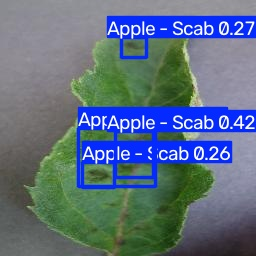

5cd3df15-31a2-4076-9d1a-8735fa1dccdf___FREC_Scab-3410_JPG.rf.b9a09e8e03c38e60f76a0fd42e4eeb08.jpg -> 9 lesion(s)


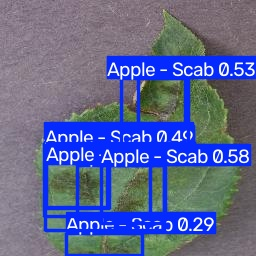

52d5723a-b498-4759-89a1-a7d815689716___FREC_Scab-3034_JPG.rf.7c9667405b2161e78becb2d628fcf4b7.jpg -> 4 lesion(s)


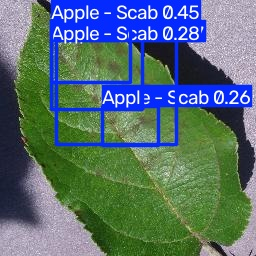

In [13]:
import random

random.seed(SEED)
val_images = sorted(glob.glob(str(Path(dataset.location) / "valid" / "images" / "*")))
sample = random.sample(val_images, k=min(4, len(val_images)))
predictions = best.predict(
    sample, imgsz=IMGSZ, conf=0.25, save=True, project=str(RUNS_DIR), name=f"{RUN_NAME}_pred", exist_ok=True
)
for r in predictions:
    print(Path(r.path).name, "->", len(r.boxes), "lesion(s)")
    display(IPImage(filename=str(Path(r.save_dir) / Path(r.path).name), width=480))

## 7 · Export to ONNX and save to Drive

A static `1×3×640×640` input at opset 17 with graph simplification. FrostGuard's `ScabVisionDetector` reads the class names and `imgsz` from the ONNX metadata that Ultralytics embeds.

In [14]:
import shutil

onnx_path = best.export(format="onnx", imgsz=IMGSZ, opset=17, simplify=True, dynamic=False)
final_model = EXPORT_DIR / EXPORT_NAME
shutil.copy(onnx_path, final_model)
print(f"Saved {final_model} ({final_model.stat().st_size / 1e6:.1f} MB)")

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/frostguard-scab/runs/scab_yolo11n/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.2 MB)

ONNX: starting export with onnx 1.23.0 opset 17...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 2.4s, saved as '/content/drive/MyDrive/frostguard-scab/runs/scab_yolo11n/weights/best.onnx' (10.1 MB)

Export complete (2.9s)
Results saved to /content/drive/MyDrive/frostguard-scab/runs/scab_yolo11n/weights/best.onnx
Predict:         yolo predict task=detect model=/content/drive/MyDrive/frostguard-scab/runs/scab_yolo11n/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model

## 8 · Verify the export with ONNX Runtime (CPU)
This is the same runtime and execution provider the local FastAPI service uses.

In [15]:
import time

import numpy as np
import onnxruntime as ort

sess = ort.InferenceSession(str(final_model), providers=["CPUExecutionProvider"])
inp, out = sess.get_inputs()[0], sess.get_outputs()[0]
print("input :", inp.name, inp.shape)
print("output:", out.name, out.shape, "(expected [1, 4 + num_classes, 8400])")
print("names :", sess.get_modelmeta().custom_metadata_map.get("names"))

x = np.random.rand(1, 3, IMGSZ, IMGSZ).astype(np.float32)
for _ in range(5):
    sess.run(None, {inp.name: x})
N = 50
t0 = time.perf_counter()
for _ in range(N):
    sess.run(None, {inp.name: x})
print(f"CPU latency on this Colab VM: {(time.perf_counter() - t0) / N * 1000:.1f} ms / image")

input : images [1, 3, 640, 640]
output: output0 [1, 5, 8400] (expected [1, 4 + num_classes, 8400])
names : {0: 'Apple - Scab'}
CPU latency on this Colab VM: 138.2 ms / image


## 9 · Bring the model home 🏠

1. In Google Drive, open **`MyDrive/frostguard-scab/models/`** and download `scab_detector.onnx`
   (or set `DOWNLOAD_TO_BROWSER = True` below).
2. Copy it into the repository as **`models/scab_detector.onnx`**. It is git-ignored on purpose.
3. Restart the API (`uvicorn src.api.app:app` or `docker compose up`). `GET /health` should now report
   `"vision_backend": "trained"` instead of `"fallback"`.

Dataset credit: *PDD – Apple – Scab* by Thesis on Roboflow Universe, licensed CC BY 4.0.

In [16]:
DOWNLOAD_TO_BROWSER = False

if DOWNLOAD_TO_BROWSER:
    from google.colab import files

    files.download(str(final_model))